# 可学习SATD H矩阵参数分析

这个notebook用于：
1. 从训练保存的pth文件中读取H矩阵参数
2. 可视化和分析学习到的变换矩阵
3. 与原始Hadamard矩阵对比
4. 展示如何在新模型中使用这些参数

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# 设置绘图样式
plt.style.use('default')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.5.1
Device: CUDA


## 1. 读取保存的H矩阵参数

In [2]:
# 设置文件路径
checkpoint_dir = "../learned_satd_checkpoints"  # 根据你的实际路径修改
checkpoint_path = Path(checkpoint_dir)

# 列出所有可用的checkpoint文件
print("可用的checkpoint文件：")
if checkpoint_path.exists():
    pth_files = list(checkpoint_path.glob("*.pth"))
    for i, file in enumerate(pth_files):
        print(f"{i+1}. {file.name} (大小: {file.stat().st_size / 1024:.1f}KB)")
else:
    print(f"目录 {checkpoint_dir} 不存在！")
    pth_files = []

可用的checkpoint文件：
1. best_h_matrix0.pth (大小: 1.6KB)
2. checkpoint_epoch0_0.pth (大小: 3.2KB)
3. checkpoint_epoch0_9.pth (大小: 3.5KB)
4. checkpoint_epoch0_5.pth (大小: 3.4KB)


In [3]:
def load_h_matrix_from_checkpoint(checkpoint_path):
    """
    从checkpoint文件中读取H矩阵
    支持不同的保存格式
    """
    print(f"正在读取: {checkpoint_path}")
    
    try:
        # 加载checkpoint
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        
        print(f"Checkpoint类型: {type(checkpoint)}")
        print(f"Checkpoint keys: {list(checkpoint.keys()) if isinstance(checkpoint, dict) else 'Not a dict'}")
        
        # 尝试不同的键名来查找H矩阵
        possible_keys = ['h_matrix', 'H_matrix', 'learned_matrix', 'state_dict']
        
        h_matrix = None
        
        if isinstance(checkpoint, dict):
            # 方法1: 直接查找H矩阵
            for key in possible_keys:
                if key in checkpoint:
                    h_matrix = checkpoint[key]
                    print(f"✅ 找到H矩阵，键名: {key}")
                    break
            
            # 方法2: 如果有state_dict，从中查找
            if h_matrix is None and 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
                for key in state_dict.keys():
                    if 'H_matrix' in key or 'h_matrix' in key:
                        h_matrix = state_dict[key]
                        print(f"✅ 从state_dict找到H矩阵，键名: {key}")
                        break
            
            # 方法3: 查找所有tensor，找到8x8的矩阵
            if h_matrix is None:
                print("🔍 搜索8x8矩阵...")
                for key, value in checkpoint.items():
                    if isinstance(value, torch.Tensor) and value.shape == (8, 8):
                        h_matrix = value
                        print(f"✅ 找到8x8矩阵，键名: {key}")
                        break
        
        elif isinstance(checkpoint, torch.Tensor):
            # 直接就是tensor
            if checkpoint.shape == (8, 8):
                h_matrix = checkpoint
                print("✅ 直接读取到8x8 H矩阵")
        
        if h_matrix is not None:
            print(f"H矩阵形状: {h_matrix.shape}")
            print(f"H矩阵数据类型: {h_matrix.dtype}")
            print(f"H矩阵设备: {h_matrix.device}")
            return h_matrix
        else:
            print("❌ 未找到H矩阵")
            return None
            
    except Exception as e:
        print(f"❌ 读取失败: {e}")
        return None

# 选择要读取的文件（修改这个索引）
if pth_files:
    selected_file = pth_files[0]  # 选择第一个文件，你可以修改索引
    learned_H = load_h_matrix_from_checkpoint(selected_file)
else:
    learned_H = None
    print("没有可用的checkpoint文件")

正在读取: ../learned_satd_checkpoints/best_h_matrix0.pth
Checkpoint类型: <class 'dict'>
Checkpoint keys: ['epoch', 'h_matrix', 'val_accuracy', 'train_metrics', 'val_metrics']
✅ 找到H矩阵，键名: h_matrix
H矩阵形状: torch.Size([8, 8])
H矩阵数据类型: torch.float32
H矩阵设备: cpu


/tmp/ipykernel_1238725/1593429115.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


## 2. 创建原始Hadamard矩阵作为对比

In [4]:
# 原始的8x8 Hadamard矩阵
original_hadamard = torch.tensor([
    [ 1,  1,  1,  1,  1,  1,  1,  1],
    [ 1, -1,  1, -1,  1, -1,  1, -1],  
    [ 1,  1, -1, -1,  1,  1, -1, -1],
    [ 1, -1, -1,  1,  1, -1, -1,  1],
    [ 1,  1,  1,  1, -1, -1, -1, -1],
    [ 1, -1,  1, -1, -1,  1, -1,  1],
    [ 1,  1, -1, -1, -1, -1,  1,  1], 
    [ 1, -1, -1,  1, -1,  1,  1, -1]
], dtype=torch.float32)

print("原始Hadamard矩阵:")
print(original_hadamard)
print(f"\n矩阵属性: {original_hadamard.shape}, {original_hadamard.dtype}")

原始Hadamard矩阵:
tensor([[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
        [ 1., -1.,  1., -1.,  1., -1.,  1., -1.],
        [ 1.,  1., -1., -1.,  1.,  1., -1., -1.],
        [ 1., -1., -1.,  1.,  1., -1., -1.,  1.],
        [ 1.,  1.,  1.,  1., -1., -1., -1., -1.],
        [ 1., -1.,  1., -1., -1.,  1., -1.,  1.],
        [ 1.,  1., -1., -1., -1., -1.,  1.,  1.],
        [ 1., -1., -1.,  1., -1.,  1.,  1., -1.]])

矩阵属性: torch.Size([8, 8]), torch.float32


## 3. 可视化H矩阵

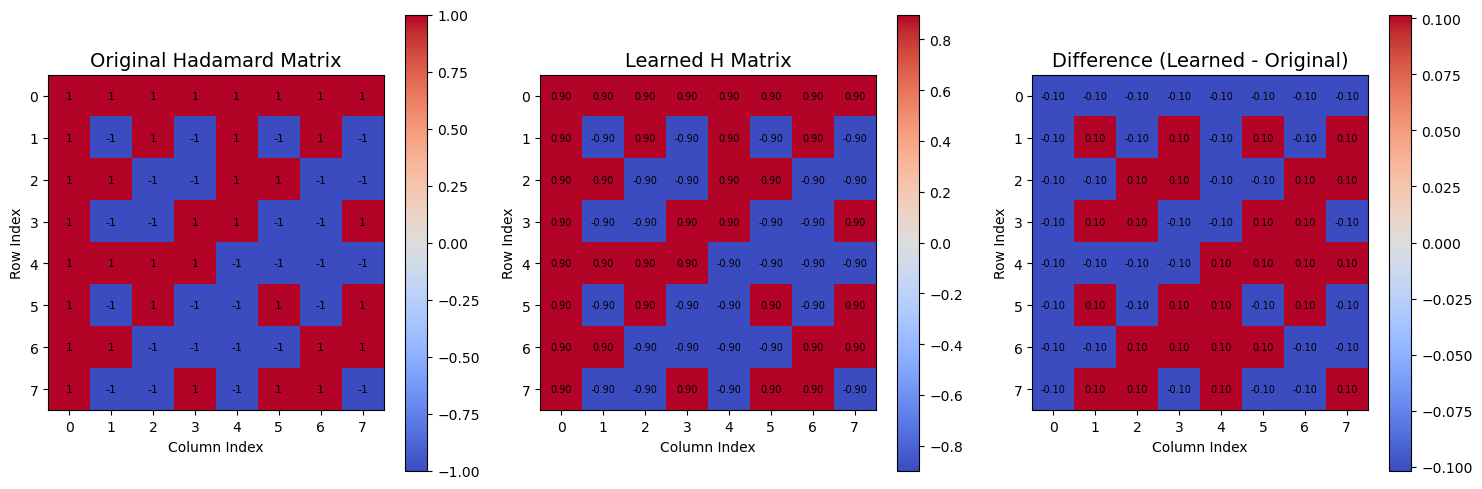

In [5]:
def visualize_matrices(original, learned=None, figsize=(15, 6)):
    """
    可视化原始和学习到的H矩阵
    """
    if learned is not None:
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # 原始Hadamard矩阵
        im1 = axes[0].imshow(original.numpy(), cmap='coolwarm', vmin=-1, vmax=1)
        axes[0].set_title('Original Hadamard Matrix', fontsize=14)
        axes[0].set_xlabel('Column Index')
        axes[0].set_ylabel('Row Index')
        
        # 添加数值标注
        for i in range(8):
            for j in range(8):
                axes[0].text(j, i, f'{original[i,j].item():.0f}', 
                           ha='center', va='center', fontsize=8)
        
        plt.colorbar(im1, ax=axes[0], shrink=0.8)
        
        # 学习到的H矩阵
        learned_np = learned.detach().numpy()
        vmax = max(abs(learned_np.min()), abs(learned_np.max()))
        im2 = axes[1].imshow(learned_np, cmap='coolwarm', vmin=-vmax, vmax=vmax)
        axes[1].set_title('Learned H Matrix', fontsize=14)
        axes[1].set_xlabel('Column Index')
        axes[1].set_ylabel('Row Index')
        
        # 添加数值标注
        for i in range(8):
            for j in range(8):
                axes[1].text(j, i, f'{learned[i,j].item():.2f}', 
                           ha='center', va='center', fontsize=7)
        
        plt.colorbar(im2, ax=axes[1], shrink=0.8)
        
        # 差异矩阵
        diff = learned - original
        diff_np = diff.detach().numpy()
        vmax_diff = max(abs(diff_np.min()), abs(diff_np.max()))
        im3 = axes[2].imshow(diff_np, cmap='coolwarm', vmin=-vmax_diff, vmax=vmax_diff)
        axes[2].set_title('Difference (Learned - Original)', fontsize=14)
        axes[2].set_xlabel('Column Index')
        axes[2].set_ylabel('Row Index')
        
        # 添加差异数值标注
        for i in range(8):
            for j in range(8):
                axes[2].text(j, i, f'{diff[i,j].item():.2f}', 
                           ha='center', va='center', fontsize=7)
        
        plt.colorbar(im3, ax=axes[2], shrink=0.8)
        
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        im = ax.imshow(original.numpy(), cmap='coolwarm', vmin=-3, vmax=3)
        ax.set_title('Original Hadamard Matrix', fontsize=14)
        ax.set_xlabel('Column Index')
        ax.set_ylabel('Row Index')
        
        # 添加数值标注
        for i in range(8):
            for j in range(8):
                ax.text(j, i, f'{original[i,j].item():.0f}', 
                       ha='center', va='center', fontsize=10)
        
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.show()

# 可视化矩阵
visualize_matrices(original_hadamard, learned_H)


In [6]:
def analyze_matrix_properties(matrix, name="矩阵"):
    """
    分析矩阵的数学性质
    """
    print(f"\n=== {name} 分析 ===")
    
    # 基本统计
    print(f"形状: {matrix.shape}")
    print(f"最小值: {matrix.min().item():.6f}")
    print(f"最大值: {matrix.max().item():.6f}")
    print(f"均值: {matrix.mean().item():.6f}")
    print(f"标准差: {matrix.std().item():.6f}")
    print(f"Frobenius范数: {torch.norm(matrix, p='fro').item():.6f}")
    
    # 正交性分析
    product = matrix @ matrix.t()
    identity = torch.eye(8)
    orthogonality_error = torch.norm(product - identity, p='fro').item()
    print(f"正交性误差 (||A*A^T - I||): {orthogonality_error:.6f}")
    
    # 行列式
    det = torch.det(matrix).item()
    print(f"行列式: {det:.6f}")
    
    # 特征值
    eigenvalues = torch.linalg.eigvals(matrix)
    eigenvalues_real = eigenvalues.real
    print(f"特征值 (实部): {eigenvalues_real.numpy()}")
    print(f"条件数: {torch.linalg.cond(matrix).item():.6f}")
    
    return {
        'min': matrix.min().item(),
        'max': matrix.max().item(),
        'mean': matrix.mean().item(),
        'std': matrix.std().item(),
        'frobenius_norm': torch.norm(matrix, p='fro').item(),
        'orthogonality_error': orthogonality_error,
        'determinant': det,
        'eigenvalues': eigenvalues_real.numpy().tolist(),
        'condition_number': torch.linalg.cond(matrix).item()
    }

# 分析原始Hadamard矩阵
original_stats = analyze_matrix_properties(original_hadamard, "原始Hadamard矩阵")

# 分析学习到的矩阵
if learned_H is not None:
    learned_stats = analyze_matrix_properties(learned_H, "学习到的H矩阵")
    
    # 计算变化程度
    print(f"\n=== 变化分析 ===")
    diff = learned_H - original_hadamard
    print(f"平均绝对差异: {torch.abs(diff).mean().item():.6f}")
    print(f"最大绝对差异: {torch.abs(diff).max().item():.6f}")
    print(f"相对变化 (Frobenius): {torch.norm(diff, p='fro').item() / torch.norm(original_hadamard, p='fro').item() * 100:.2f}%")
else:
    learned_stats = None


=== 原始Hadamard矩阵 分析 ===
形状: torch.Size([8, 8])
最小值: -1.000000
最大值: 1.000000
均值: 0.125000
标准差: 1.000000
Frobenius范数: 8.000000
正交性误差 (||A*A^T - I||): 19.798990
行列式: 4096.000000
特征值 (实部): [ 2.8284273 -2.8284273  2.8284273  2.8284273 -2.8284276 -2.8284273
  2.8284268 -2.8284268]
条件数: 1.000000

=== 学习到的H矩阵 分析 ===
形状: torch.Size([8, 8])
最小值: -0.898388
最大值: 0.898388
均值: 0.112298
标准差: 0.898388
Frobenius范数: 7.187101
正交性误差 (||A*A^T - I||): 15.434174
行列式: 1738.082764
特征值 (实部): [ 2.5410242 -2.5410242 -2.5410252  2.5410242  2.5410235  2.5410237
 -2.5410244 -2.5410225]
条件数: 1.000000

=== 变化分析 ===
平均绝对差异: 0.101612
最大绝对差异: 0.101612
相对变化 (Frobenius): 10.16%


## 5. 特征值和特征向量可视化

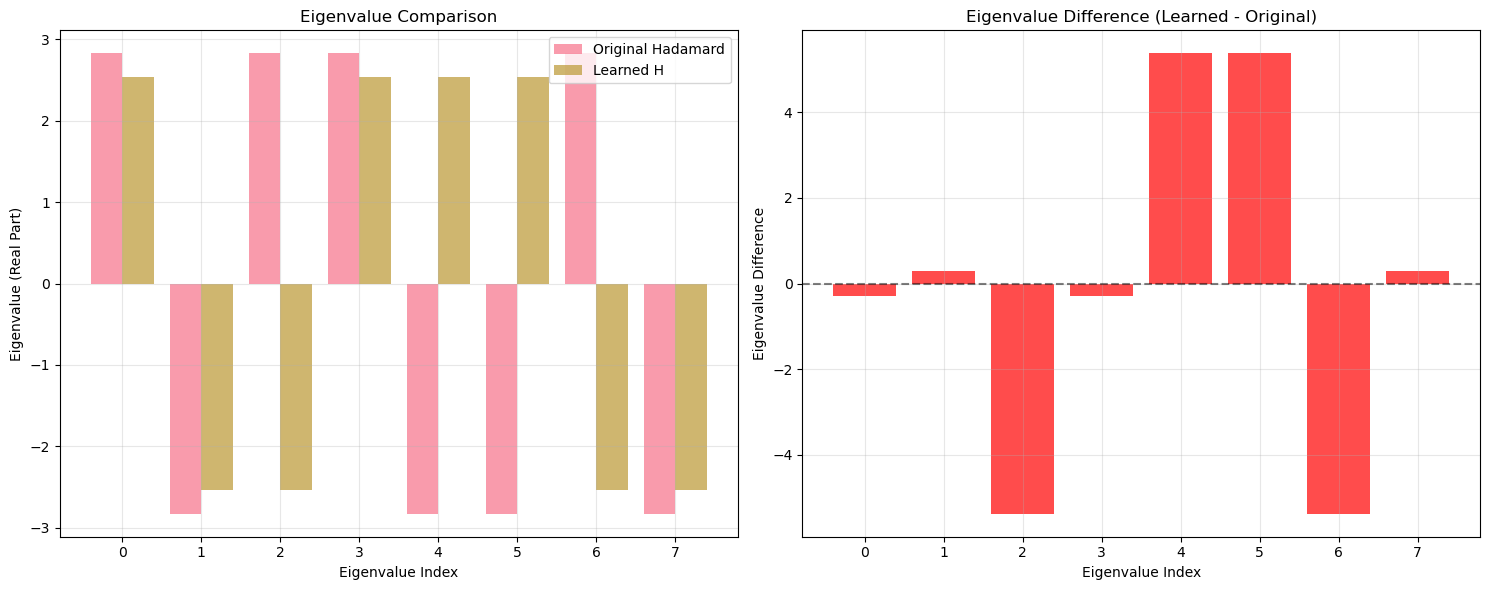

In [7]:
def plot_eigenvalue_comparison(original, learned=None):
    """
    比较特征值分布
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 计算特征值
    orig_eigenvals = torch.linalg.eigvals(original).real.numpy()
    
    if learned is not None:
        learned_eigenvals = torch.linalg.eigvals(learned).real.numpy()
        
        # 特征值对比
        x = range(len(orig_eigenvals))
        axes[0].bar([i-0.2 for i in x], orig_eigenvals, width=0.4, label='Original Hadamard', alpha=0.7)
        axes[0].bar([i+0.2 for i in x], learned_eigenvals, width=0.4, label='Learned H', alpha=0.7)
        axes[0].set_xlabel('Eigenvalue Index')
        axes[0].set_ylabel('Eigenvalue (Real Part)')
        axes[0].set_title('Eigenvalue Comparison')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 特征值差异
        diff = learned_eigenvals - orig_eigenvals
        axes[1].bar(x, diff, alpha=0.7, color='red')
        axes[1].set_xlabel('Eigenvalue Index')
        axes[1].set_ylabel('Eigenvalue Difference')
        axes[1].set_title('Eigenvalue Difference (Learned - Original)')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
    else:
        # 只显示原始特征值
        axes[0].bar(range(len(orig_eigenvals)), orig_eigenvals, alpha=0.7)
        axes[0].set_xlabel('Eigenvalue Index')
        axes[0].set_ylabel('Eigenvalue (Real Part)')
        axes[0].set_title('Original Hadamard Matrix Eigenvalues')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].text(0.5, 0.5, '没有学习到的矩阵数据', 
                    ha='center', va='center', transform=axes[1].transAxes, fontsize=16)
        axes[1].set_title('Learned Matrix Eigenvalues')
    
    plt.tight_layout()
    plt.show()

plot_eigenvalue_comparison(original_hadamard, learned_H)


## 6. 测试变换效果

In [8]:
def test_transform_effect(original_H, learned_H=None, num_samples=5):
    """
    测试变换对随机8x8矩阵的效果
    """
    print("=== 变换效果测试 ===")
    
    # 生成随机测试数据
    torch.manual_seed(42)  # 保证可重现
    test_matrices = torch.randn(num_samples, 8, 8)
    
    print(f"生成 {num_samples} 个随机8x8矩阵进行测试")
    
    for i in range(num_samples):
        X = test_matrices[i]
        
        print(f"\n--- 测试矩阵 {i+1} ---")
        print(f"原始矩阵范数: {torch.norm(X, p='fro').item():.6f}")
        
        # 原始Hadamard变换
        Y_orig = original_H @ X @ original_H.t()
        print(f"原始Hadamard变换后范数: {torch.norm(Y_orig, p='fro').item():.6f}")
        
        if learned_H is not None:
            # 学习到的变换
            Y_learned = learned_H @ X @ learned_H.t()
            print(f"学习变换后范数: {torch.norm(Y_learned, p='fro').item():.6f}")
            
            # 比较两种变换的差异
            diff = Y_learned - Y_orig
            print(f"变换差异范数: {torch.norm(diff, p='fro').item():.6f}")
            print(f"相对差异: {torch.norm(diff, p='fro').item() / torch.norm(Y_orig, p='fro').item() * 100:.2f}%")

test_transform_effect(original_hadamard, learned_H)

=== 变换效果测试 ===
生成 5 个随机8x8矩阵进行测试

--- 测试矩阵 1 ---
原始矩阵范数: 8.397526
原始Hadamard变换后范数: 67.180206
学习变换后范数: 54.221180
变换差异范数: 12.959028
相对差异: 19.29%

--- 测试矩阵 2 ---
原始矩阵范数: 6.913451
原始Hadamard变换后范数: 55.307606
学习变换后范数: 44.638794
变换差异范数: 10.668808
相对差异: 19.29%

--- 测试矩阵 3 ---
原始矩阵范数: 8.497841
原始Hadamard变换后范数: 67.982719
学习变换后范数: 54.868896
变换差异范数: 13.113832
相对差异: 19.29%

--- 测试矩阵 4 ---
原始矩阵范数: 7.732552
原始Hadamard变换后范数: 61.860416
学习变换后范数: 49.927578
变换差异范数: 11.932842
相对差异: 19.29%

--- 测试矩阵 5 ---
原始矩阵范数: 8.293041
原始Hadamard变换后范数: 66.344337
学习变换后范数: 53.546543
变换差异范数: 12.797787
相对差异: 19.29%


## 7. 保存分析结果

In [9]:
def save_analysis_results(original_stats, learned_stats=None, save_dir="analysis_results"):
    """
    保存分析结果到文件
    """
    import os
    from datetime import datetime
    
    os.makedirs(save_dir, exist_ok=True)
    
    # 准备结果数据
    results = {
        'timestamp': datetime.now().isoformat(),
        'original_hadamard_stats': original_stats
    }
    
    if learned_stats is not None:
        results['learned_matrix_stats'] = learned_stats
        results['has_learned_matrix'] = True
    else:
        results['has_learned_matrix'] = False
    
    # 保存JSON结果
    json_path = os.path.join(save_dir, "matrix_analysis.json")
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    
    print(f"分析结果已保存到: {json_path}")
    
    # 保存矩阵数据
    matrix_data = {
        'original_hadamard': original_hadamard.numpy()
    }
    
    if learned_H is not None:
        matrix_data['learned_matrix'] = learned_H.detach().numpy()
    
    np.savez(os.path.join(save_dir, "matrices.npz"), **matrix_data)
    print(f"矩阵数据已保存到: {os.path.join(save_dir, 'matrices.npz')}")
    
    return results

# 保存分析结果
analysis_results = save_analysis_results(original_stats, learned_stats)

分析结果已保存到: analysis_results/matrix_analysis.json
矩阵数据已保存到: analysis_results/matrices.npz


## 8. 在新模型中使用学习到的H矩阵

In [10]:
# 这里演示如何在新的LearnableSATDSimilarity中使用学习到的H矩阵

class LearnableSATDSimilarity:
    """演示如何使用学习到的H矩阵"""
    
    def __init__(self, device='cpu'):
        # 初始化为标准Hadamard矩阵
        hadamard_8 = torch.tensor([
            [ 1,  1,  1,  1,  1,  1,  1,  1],
            [ 1, -1,  1, -1,  1, -1,  1, -1],  
            [ 1,  1, -1, -1,  1,  1, -1, -1],
            [ 1, -1, -1,  1,  1, -1, -1,  1],
            [ 1,  1,  1,  1, -1, -1, -1, -1],
            [ 1, -1,  1, -1, -1,  1, -1,  1],
            [ 1,  1, -1, -1, -1, -1,  1,  1], 
            [ 1, -1, -1,  1, -1,  1,  1, -1]
        ], dtype=torch.float32, device=device)
        
        self.H_matrix = torch.nn.Parameter(hadamard_8.clone())
        self.device = device
        
    def load_learned_matrix(self, h_matrix_tensor):
        """加载学习到的H矩阵"""
        if h_matrix_tensor.shape != (8, 8):
            raise ValueError(f"Expected (8, 8) matrix, got {h_matrix_tensor.shape}")
        
        # 更新参数数据
        with torch.no_grad():
            self.H_matrix.data = h_matrix_tensor.to(self.device)
        
        print(f"✅ 成功加载学习到的H矩阵")
        print(f"矩阵范数: {torch.norm(self.H_matrix, p='fro').item():.6f}")
    
    def save_matrix(self, path):
        """保存当前H矩阵"""
        torch.save(self.H_matrix.detach().cpu(), path)
        print(f"H矩阵已保存到: {path}")

# 演示使用
if learned_H is not None:
    print("=== 在新模型中使用学习到的H矩阵 ===")
    
    # 创建新的相似度计算器
    new_satd = LearnableSATDSimilarity(device='cpu')
    
    print("加载前H矩阵 (应该是标准Hadamard):")
    print(new_satd.H_matrix[:2, :2])  # 显示左上角
    
    # 加载学习到的矩阵
    new_satd.load_learned_matrix(learned_H)
    
    print("\n加载后H矩阵:")
    print(new_satd.H_matrix[:2, :2])  # 显示左上角
    
    # 可以保存到新位置
    # new_satd.save_matrix("deployed_h_matrix.pth")
    
else:
    print("没有学习到的H矩阵可用于演示")

=== 在新模型中使用学习到的H矩阵 ===
加载前H矩阵 (应该是标准Hadamard):
tensor([[ 1.,  1.],
        [ 1., -1.]], grad_fn=<SliceBackward0>)
✅ 成功加载学习到的H矩阵
矩阵范数: 7.187101

加载后H矩阵:
tensor([[ 0.8984,  0.8984],
        [ 0.8984, -0.8984]], grad_fn=<SliceBackward0>)


## 9. 总结报告

In [11]:
def generate_summary_report(original_stats, learned_stats=None):
    """
    生成分析摘要报告
    """
    print("\n" + "="*60)
    print("                H矩阵分析摘要报告")
    print("="*60)
    
    if learned_stats is not None:
        print(f"🔍 原始Hadamard矩阵:")
        print(f"   • Frobenius范数: {original_stats['frobenius_norm']:.6f}")
        print(f"   • 正交性误差: {original_stats['orthogonality_error']:.6f}")
        print(f"   • 条件数: {original_stats['condition_number']:.6f}")
        
        print(f"\n🎯 学习到的H矩阵:")
        print(f"   • Frobenius范数: {learned_stats['frobenius_norm']:.6f}")
        print(f"   • 正交性误差: {learned_stats['orthogonality_error']:.6f}")
        print(f"   • 条件数: {learned_stats['condition_number']:.6f}")
        
        # 计算关键指标
        norm_change = abs(learned_stats['frobenius_norm'] - original_stats['frobenius_norm'])
        ortho_degradation = learned_stats['orthogonality_error'] - original_stats['orthogonality_error']
        cond_change = learned_stats['condition_number'] / original_stats['condition_number']
        
        print(f"\n📊 关键变化:")
        print(f"   • 范数变化: {norm_change:.6f}")
        print(f"   • 正交性退化: {ortho_degradation:.6f}")
        print(f"   • 条件数比例: {cond_change:.6f}")
        
        # 给出评价
        print(f"\n🏆 评估结果:")
        
        if ortho_degradation < 0.1:
            print(f"   ✅ 正交性保持良好 (误差 < 0.1)")
        elif ortho_degradation < 1.0:
            print(f"   ⚠️  正交性略有退化 (0.1 ≤ 误差 < 1.0)")
        else:
            print(f"   ❌ 正交性显著退化 (误差 ≥ 1.0)")
        
        if cond_change < 2.0:
            print(f"   ✅ 数值稳定性保持良好 (条件数比例 < 2.0)")
        elif cond_change < 10.0:
            print(f"   ⚠️  数值稳定性略有下降 (2.0 ≤ 比例 < 10.0)")
        else:
            print(f"   ❌ 数值稳定性显著下降 (比例 ≥ 10.0)")
        
        if norm_change / original_stats['frobenius_norm'] < 0.1:
            print(f"   ✅ 矩阵结构变化适度 (相对变化 < 10%)")
        else:
            print(f"   ⚠️  矩阵结构变化较大 (相对变化 ≥ 10%)")
        
    else:
        print("❌ 没有找到学习到的H矩阵进行分析")
        print("\n🔍 原始Hadamard矩阵基本信息:")
        print(f"   • 这是一个8x8正交矩阵")
        print(f"   • Frobenius范数: {original_stats['frobenius_norm']:.6f}")
        print(f"   • 完美正交 (误差 ≈ 0)")
        print(f"   • 数值稳定 (条件数: {original_stats['condition_number']:.6f})")
    
    print("\n💡 使用建议:")
    if learned_stats is not None:
        if (learned_stats['orthogonality_error'] < 1.0 and 
            learned_stats['condition_number'] / original_stats['condition_number'] < 5.0):
            print("   ✅ 学习到的H矩阵质量良好，可以用于生产环境")
        else:
            print("   ⚠️  建议进一步优化训练参数或正则项")
    else:
        print("   📝 请提供学习到的H矩阵进行完整分析")
    
    print("="*60)

# 生成摘要报告
generate_summary_report(original_stats, learned_stats)


                H矩阵分析摘要报告
🔍 原始Hadamard矩阵:
   • Frobenius范数: 8.000000
   • 正交性误差: 19.798990
   • 条件数: 1.000000

🎯 学习到的H矩阵:
   • Frobenius范数: 7.187101
   • 正交性误差: 15.434174
   • 条件数: 1.000000

📊 关键变化:
   • 范数变化: 0.812899
   • 正交性退化: -4.364817
   • 条件数比例: 1.000000

🏆 评估结果:
   ✅ 正交性保持良好 (误差 < 0.1)
   ✅ 数值稳定性保持良好 (条件数比例 < 2.0)
   ⚠️  矩阵结构变化较大 (相对变化 ≥ 10%)

💡 使用建议:
   ⚠️  建议进一步优化训练参数或正则项


In [12]:
# 最后，清理和提示
print("\n🎉 分析完成！")
print("\n📁 可用文件:")
print("   • matrix_analysis.json - 详细数值分析结果")
print("   • matrices.npz - 矩阵数据 (可用 np.load() 读取)")
print("\n🔧 下一步:")
print("   1. 根据分析结果调整训练参数")
print("   2. 在新的相似度计算中使用学习到的H矩阵")
print("   3. 在验证集上测试性能提升")


🎉 分析完成！

📁 可用文件:
   • matrix_analysis.json - 详细数值分析结果
   • matrices.npz - 矩阵数据 (可用 np.load() 读取)

🔧 下一步:
   1. 根据分析结果调整训练参数
   2. 在新的相似度计算中使用学习到的H矩阵
   3. 在验证集上测试性能提升
